In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df=pd.read_csv("/content/shopify_stock.csv")

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2469 non-null   object 
 1   open       2469 non-null   float64
 2   high       2469 non-null   float64
 3   low        2469 non-null   float64
 4   close      2469 non-null   float64
 5   adj_close  2469 non-null   float64
 6   volume     2469 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.2+ KB


In [99]:
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [100]:
df.describe()

,open,high,low,close,adj_close,volume
count,2469.000000,2469.000000,2469.000000,2469.000000,2469.000000,2.469000e+03
mean,48.464345,49.505495,47.347795,48.456613,48.456613,1.657049e+07
std,43.633916,44.470235,42.642546,43.573362,43.573362,1.436909e+07
min,1.939000,1.985000,1.848000,1.933000,1.933000,1.039000e+06
25%,10.479000,10.635000,10.275000,10.450000,10.450000,8.098000e+06
50%,35.640999,36.879002,34.655998,35.874001,35.874001,1.275860e+07
75%,76.080002,77.169998,74.589996,75.800003,75.800003,2.060200e+07
max,171.800003,176.291794,168.509506,169.059998,169.059998,2.089590e+08


In [101]:
df.shape

(2469, 7)

In [102]:
df["date"]=pd.to_datetime(df["date"],utc=True)

In [103]:
df['date'].dtype

datetime64[ns, UTC]

In [104]:
print(df.isnull().sum())

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64


In [105]:
df=df.dropna()

In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df.drop_duplicates()



,date,open,high,low,close,adj_close,volume
0,2015-05-21 04:00:00+00:00,2.800000,2.874000,2.411000,2.568000,2.568000,123039000
1,2015-05-22 04:00:00+00:00,2.607000,3.110000,2.600000,2.831000,2.831000,28412000
2,2015-05-26 04:00:00+00:00,2.980000,3.034000,2.908000,2.965000,2.965000,8202000
3,2015-05-27 04:00:00+00:00,3.067000,3.081000,2.700000,2.750000,2.750000,7976000
4,2015-05-28 04:00:00+00:00,2.755000,2.774000,2.648000,2.745000,2.745000,4000000
...,...,...,...,...,...,...,...
2464,2025-03-10 04:00:00+00:00,96.070000,96.186996,91.690002,92.750000,92.750000,16385300
2465,2025-03-11 04:00:00+00:00,92.750000,95.109001,91.150002,92.949997,92.949997,12127100
2466,2025-03-12 04:00:00+00:00,96.669998,99.135002,95.290001,96.529999,96.529999,8531900
2467,2025-03-13 04:00:00+00:00,95.169998,95.529999,89.099998,90.589996,90.589996,11076400


In [108]:
df.sort_values("date")

,date,open,high,low,close,adj_close,volume
0,2015-05-21 04:00:00+00:00,2.800000,2.874000,2.411000,2.568000,2.568000,123039000
1,2015-05-22 04:00:00+00:00,2.607000,3.110000,2.600000,2.831000,2.831000,28412000
2,2015-05-26 04:00:00+00:00,2.980000,3.034000,2.908000,2.965000,2.965000,8202000
3,2015-05-27 04:00:00+00:00,3.067000,3.081000,2.700000,2.750000,2.750000,7976000
4,2015-05-28 04:00:00+00:00,2.755000,2.774000,2.648000,2.745000,2.745000,4000000
...,...,...,...,...,...,...,...
2464,2025-03-10 04:00:00+00:00,96.070000,96.186996,91.690002,92.750000,92.750000,16385300
2465,2025-03-11 04:00:00+00:00,92.750000,95.109001,91.150002,92.949997,92.949997,12127100
2466,2025-03-12 04:00:00+00:00,96.669998,99.135002,95.290001,96.529999,96.529999,8531900
2467,2025-03-13 04:00:00+00:00,95.169998,95.529999,89.099998,90.589996,90.589996,11076400


In [109]:
df["Daily_Delta"] = df["close"] - df["open"]

In [110]:
df["Daily_Return"] = ((df["close"] - df["open"]) / df["open"]) * 100

In [111]:
print(df[["date", "open", "close", "Daily_Delta", "Daily_Return"]].head())

                       date   open  close  Daily_Delta  Daily_Return
0 2015-05-21 04:00:00+00:00  2.800  2.568       -0.232     -8.285710
1 2015-05-22 04:00:00+00:00  2.607  2.831        0.224      8.592250
2 2015-05-26 04:00:00+00:00  2.980  2.965       -0.015     -0.503359
3 2015-05-27 04:00:00+00:00  3.067  2.750       -0.317    -10.335830
4 2015-05-28 04:00:00+00:00  2.755  2.745       -0.010     -0.362985


In [112]:
average_volume = df["volume"].mean()
maximum_volume = df["volume"].max()
minimum_volume = df["volume"].min()

print("Average Volume:", average_volume)
print("Maximum Volume:", maximum_volume)
print("Minimum Volume:", minimum_volume)

Average Volume: 16570491.778047793
Maximum Volume: 208959000
Minimum Volume: 1039000


In [113]:
threshold = 2 * average_volume

In [114]:
anomalous_days = df[df["volume"] > threshold]

In [115]:
print("\nAnomalous Trading Days:")
print(anomalous_days[["date","open","close","Daily_Delta","Daily_Return","volume"]])


Anomalous Trading Days:
                          date        open       close  Daily_Delta  \
0    2015-05-21 04:00:00+00:00    2.800000    2.568000    -0.232000   
186  2016-02-17 05:00:00+00:00    2.429000    2.237000    -0.192000   
303  2016-08-03 04:00:00+00:00    3.497000    3.679000     0.182000   
313  2016-08-17 04:00:00+00:00    3.890000    3.874000    -0.016000   
410  2017-01-05 05:00:00+00:00    4.447000    4.768000     0.321000   
...                        ...         ...         ...          ...   
2197 2024-02-13 05:00:00+00:00   77.800003   77.180000    -0.620003   
2256 2024-05-08 04:00:00+00:00   63.669998   62.730000    -0.939999   
2318 2024-08-07 04:00:00+00:00   64.500000   63.889999    -0.610001   
2386 2024-11-12 05:00:00+00:00  107.519997  108.919998     1.400002   
2446 2025-02-11 05:00:00+00:00  122.279999  123.589996     1.309998   

      Daily_Return     volume  
0        -8.285710  123039000  
186      -7.904484   34914000  
303       5.204459   33537

In [116]:
mean_return = df["Daily_Return"].mean()
variance_return = df["Daily_Return"].var()
std_return = df["Daily_Return"].std()

print("Mean Return:", mean_return)
print("Variance:", variance_return)
print("Standard Deviation:", std_return)

Mean Return: 0.08640631099421993
Variance: 9.733081984179565
Standard Deviation: 3.1197887723657773


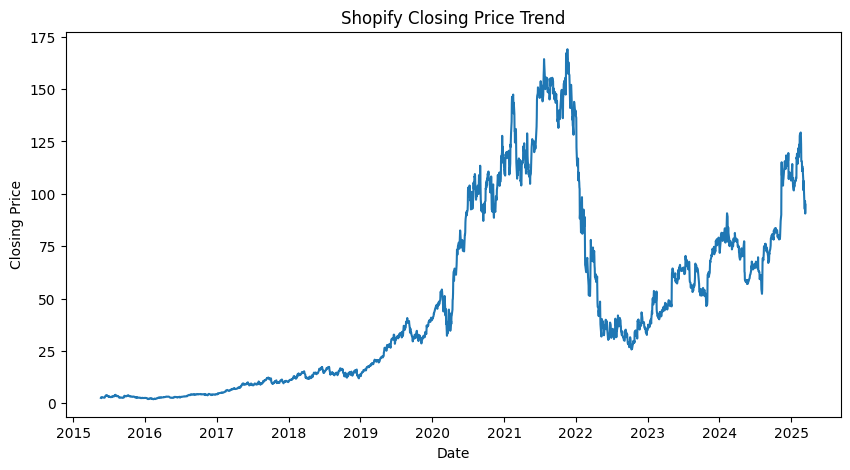

In [119]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["close"])

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Shopify Closing Price Trend")
plt.show()

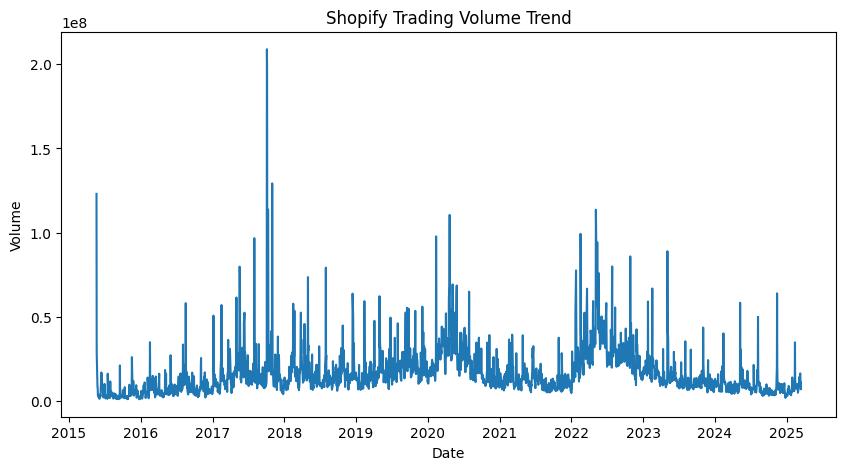

<Figure size 640x480 with 0 Axes>

In [120]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["volume"])

plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("Shopify Trading Volume Trend")

plt.show()
plt.savefig("chart.png")

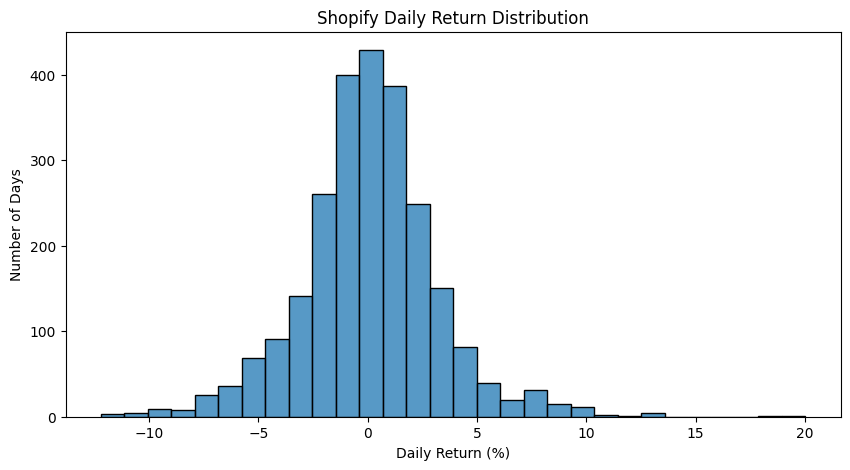

In [121]:
plt.figure(figsize=(10,5))

sns.histplot(df["Daily_Return"], bins=30)

plt.xlabel("Daily Return (%)")
plt.ylabel("Number of Days")
plt.title("Shopify Daily Return Distribution")

plt.show()